## Processamento Digital de Sinais
### Módulo 1 – Introdução
#### Atividade Computacional

Rode cada um dos códigos

Essa função, foi criada como uma forma de realizar a verificação de periodicidade de uma função por meio da propriedade de uma função periódica

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def verificar_periodicidade(x, nome, periodo_max=200, tol=1e-8):
    N = len(x)
    limite = min(periodo_max, N // 2)  # Criar um limite pois periodo a ser textado não pode ser maior que a metade da seqqu^^encia
    for T in range(1, limite + 1):
        # Compara os elementos deslocados
        if np.allclose(x[T:], x[:-T], atol=tol):
            # É PRECISO VERIficar o periodo se mantem para o intervalo o pois é reduntante (redundante com allclose)
            return True, T
    return False, None

## Parte A - Geração e visualização de sequências

Considere o índice $n = 0, 1, \dots, 20$ e gere:

* **Sequência constante:** $x_1[n] = 1$
* **Exponencial discreta:** $x_2[n] = 0,8^n$
* **Senoidal discreta:** $x_3[n] = \sin(0,3\pi n)$

Represente cada uma com **stem** e descreva, em 2–3 linhas, o comportamento observado.

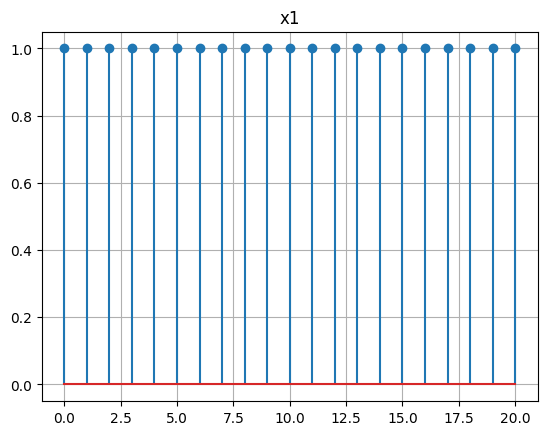

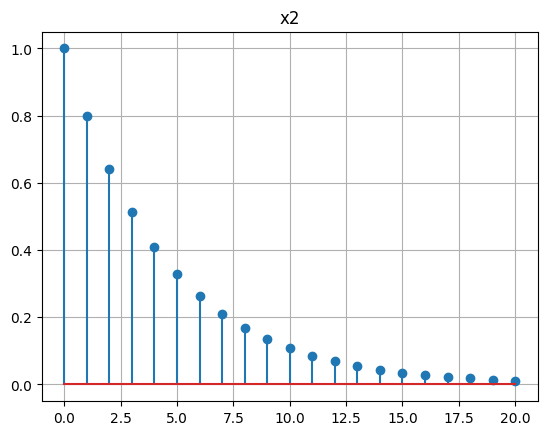

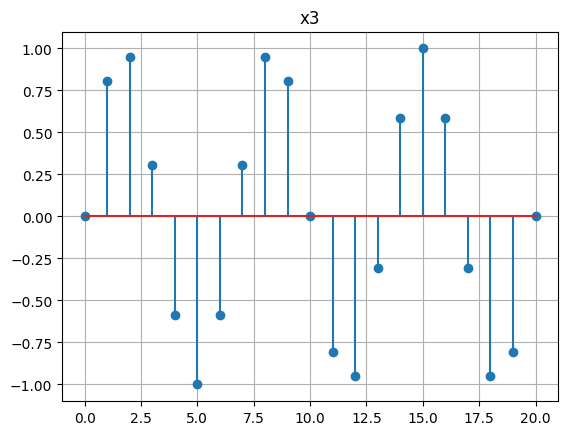

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(0, 21)
x1 = np.ones_like(n)
x2 = 0.8**n
x3 = np.sin(0.3 * np.pi * n)

for x, name in [(x1,'x1'),(x2,'x2'),(x3,'x3')]:
  plt.figure()
  plt.stem(n, x)
  plt.title(name)
  plt.grid(True)

plt.show()

## Parte B – Frequência digital e periodicidade

### Questão:

Fixe $\phi = 0$ e compare:

$$x_a[n] = \cos \left( \frac{\pi}{2} n \right), \quad x_b[n] = \cos \left( \frac{\pi\sqrt{2}}{2} n \right)$$

1. **Qual deles é periódico? Estime o período de $x_a[n]$ por inspeção.**

2. **Explique por que $x_b[n]$ não repete exatamente.**

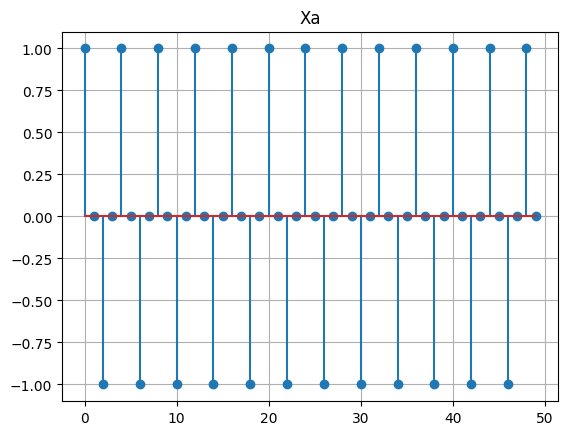

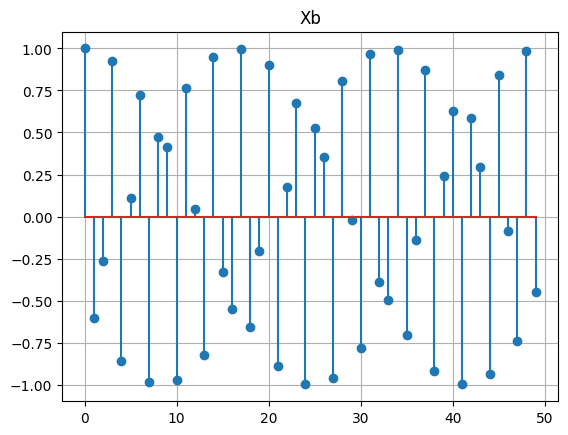

Texte para verificar periodicidade
Xa: É periódico. Período fundamental T = 4
Xb: Não é periódico


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(0, 50)
xa = np.cos(0.5 * np.pi * n)
xb = np.cos(np.pi * np.sqrt(2) * n / 2)

for x, name in [(xa,'Xa'),(xb,'Xb')]:
  plt.figure()
  plt.stem(n, x)
  plt.title(name)
  plt.grid(True)

plt.show()

print("Texte para verificar periodicidade") #Depende muito do valor colocado no tamanho da sequência
for x, nome in [(xa, 'Xa'), (xb, 'Xb')]:
    periodico, periodo = verificar_periodicidade(x, nome)
    if periodico:
        print(f"{nome}: É periódico. Período fundamental T = {periodo}")
    else:
        print(f"{nome}: Não é periódico")

## Parte C – Relação $f_0$ (Hz) e $\omega_0$ (rad/amostra)

### Questão:

Considere um seno analógico $x(t) = \cos(2\pi f_0 t)$ com $f_0 = 1$ kHz. Para as frequências de amostragem $f_s \in \{8 \text{ kHz}, 44,1 \text{ kHz}\}$:

1. **Calcule $\omega_0 = \frac{2\pi f_0}{f_s}$**

2. **Gere as sequências $x[n] = \cos(\omega_0 n)$ e compare as formas de onda discretas em um mesmo intervalo de tempo (por exemplo, 10 ms).**

[0.7853981633974483, 0.14247585730565954]
fs = 8000 Hz → ω0 = 0.78540 rad/amostra


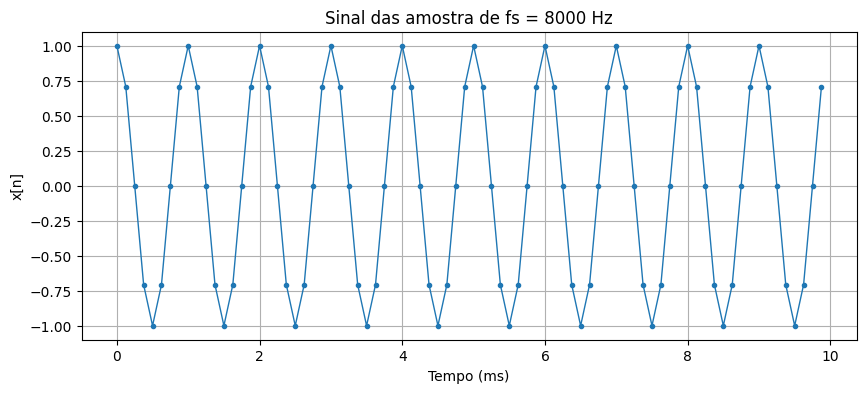

fs = 44100 Hz → ω0 = 0.14248 rad/amostra


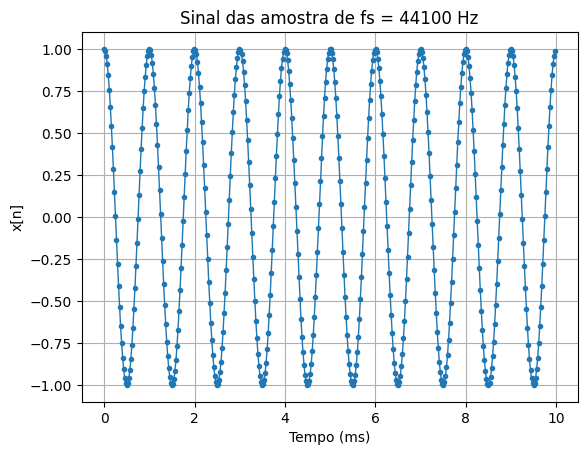

In [ ]:
f0 = 1000
fs = [8000, 44100]
t = 0.01 # 10 ms

Wo = [2 * np.pi * f0/freq_s for freq_s in fs]
print(Wo)

plt.figure(figsize=(10, 4))

for f in fs:
    ω0 = 2 * np.pi * f0 / f
    print(f'fs = {f} Hz → ω0 = {ω0:.5f} rad/amostra')

    N = int(np.ceil(t * f))
    n = np.arange(N)
    x = np.cos(ω0 * n)

    tempo_ms = n / f * 1000   # vetor de tempo em ms (variável diferente de t)

    plt.plot(tempo_ms, x, 'o-', markersize=3, linewidth=1)

    plt.xlabel('Tempo (ms)')
    plt.ylabel('x[n]')
    plt.title(f'Sinal das amostra de fs = {f} Hz')
    plt.grid(True)
    plt.show()